## Cell 1 — Setup

In [5]:
import os
import json
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Project paths
RESULTS_DIR = 'results'        # Adjust if your JSONs are elsewhere
FIGURES_DIR = 'figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

# Consistent colour palette for the report
COLORS = {
    'exp1_efficientnet_b4':       '#1B2A4A',
    'exp2_efficientnet_b3':       '#0D9488',
    'exp4_convnext_small':        '#F59E0B',
    'exp3_swin_base':             '#7C3AED',
    'exp5_deit_small':            '#DC2626',
    'exp4b_swin_base_focal':      '#475569',
    'exp_final_swin_15epoch':     '#000000',
}

# Pretty display names for the report
DISPLAY_NAMES = {
    'exp1_efficientnet_b4':     'EfficientNet-B4 (CE, 5 ep)',
    'exp2_efficientnet_b3':     'EfficientNet-B3 (CE, 5 ep)',
    'exp4_convnext_small':      'ConvNeXt-Small (CE, 5 ep)',
    'exp3_swin_base':           'Swin-Base (CE, 5 ep)',
    'exp5_deit_small':          'DeiT-Small (CE, 5 ep)',
    'exp4b_swin_base_focal':    'Swin-Base (Focal, 5 ep)',
    'exp_final_swin_15epoch':   'Swin-Base (CE, 15 ep)',
}

# Architecture type for grouping
ARCH_TYPE = {
    'exp1_efficientnet_b4':     'CNN',
    'exp2_efficientnet_b3':     'CNN',
    'exp4_convnext_small':      'CNN',
    'exp3_swin_base':           'Transformer',
    'exp5_deit_small':          'Transformer',
    'exp4b_swin_base_focal':    'Transformer',
    'exp_final_swin_15epoch':   'Transformer',
}

print('Setup done.')

Setup done.


## Cell 2 — Load all experiment results

In [7]:
results = {}

for json_path in sorted(glob.glob(os.path.join(RESULTS_DIR, 'exp*.json'))):
    exp_name = os.path.splitext(os.path.basename(json_path))[0]
    with open(json_path) as f:
        data = json.load(f)
    results[exp_name] = data
    print(f'Loaded {exp_name:35s} best AUC: {data["best_auc"]:.4f}')

print(f'\nTotal experiments loaded: {len(results)}')

Loaded exp1_efficientnet_b4                best AUC: 0.9085
Loaded exp2_efficientnet_b3                best AUC: 0.9126
Loaded exp3_swin_base                      best AUC: 0.9363
Loaded exp4_convnext_small                 best AUC: 0.9289
Loaded exp4b_swin_base_focal               best AUC: 0.9294
Loaded exp5_deit_small                     best AUC: 0.9183
Loaded exp_final_swin_15epoch              best AUC: 0.9275

Total experiments loaded: 7


## Cell 3 — Summary table

In [8]:
rows = []
for exp_name, data in results.items():
    h = data['history']
    total_time = sum(h['time_min'])
    best_epoch = int(np.argmax(h['val_auc'])) + 1
    final_train_loss = h['train_loss'][-1]
    final_val_loss = h['val_loss'][-1]
    
    rows.append({
        'Experiment':    DISPLAY_NAMES.get(exp_name, exp_name),
        'Type':          ARCH_TYPE.get(exp_name, ''),
        'Model':         data.get('model_name', '-'),
        'Params':        f'{data.get("n_params", 0)/1e6:.1f}M' if data.get('n_params') else '-',
        'Img':           data.get('image_size', '-'),
        'Epochs':        len(h['val_auc']),
        'Best AUC':      data['best_auc'],
        'Best epoch':    best_epoch,
        'Final train L': round(final_train_loss, 4),
        'Final val L':   round(final_val_loss, 4),
        'Time (min)':    round(total_time, 1),
    })

summary = pd.DataFrame(rows).sort_values('Best AUC', ascending=False)
summary.to_csv(os.path.join(FIGURES_DIR, 'summary_table.csv'), index=False)
summary

,Experiment,Type,Model,Params,Img,Epochs,Best AUC,Best epoch,Final train L,Final val L,Time (min)
2,"Swin-Base (CE, 5 ep)",Transformer,swin_base_patch4_window7_224,86.8M,224,5,0.936317,5,0.0479,0.0602,64.6
4,"Swin-Base (Focal, 5 ep)",Transformer,swin_base_patch4_window7_224,86.8M,224,5,0.929368,5,0.0036,0.0045,62.0
3,"ConvNeXt-Small (CE, 5 ep)",CNN,convnext_small,49.5M,384,5,0.928864,5,0.0514,0.0600,66.4
6,"Swin-Base (CE, 15 ep)",Transformer,swin_base_patch4_window7_224,86.8M,224,15,0.927535,14,0.0142,0.1031,179.7
5,"DeiT-Small (CE, 5 ep)",Transformer,deit_small_patch16_224,21.7M,224,5,0.918294,5,0.0042,0.0045,64.0
1,"EfficientNet-B3 (CE, 5 ep)",CNN,tf_efficientnet_b3_ns,10.7M,384,5,0.912595,3,0.0593,0.0637,67.4
0,"EfficientNet-B4 (CE, 5 ep)",CNN,tf_efficientnet_b4_ns,17.6M,384,5,0.908467,4,0.0639,0.0672,68.4


## Cell 4 — Architecture comparison: validation AUC over epochs

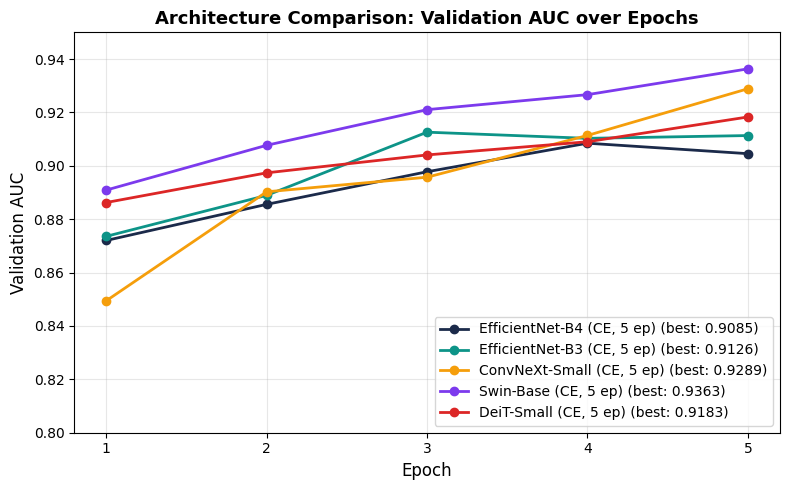

Saved: fig_architecture_auc.png and .pdf


In [9]:
# Only the 5 architecture comparison runs (5 epochs, CE)
arch_runs = [
    'exp1_efficientnet_b4',
    'exp2_efficientnet_b3',
    'exp4_convnext_small',
    'exp3_swin_base',
    'exp5_deit_small',
]

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
for exp in arch_runs:
    if exp not in results:
        continue
    h = results[exp]['history']
    epochs_x = range(1, len(h['val_auc']) + 1)
    ax.plot(epochs_x, h['val_auc'], 'o-', linewidth=2, markersize=6,
            label=f'{DISPLAY_NAMES[exp]} (best: {results[exp]["best_auc"]:.4f})',
            color=COLORS[exp])

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Validation AUC', fontsize=12)
ax.set_title('Architecture Comparison: Validation AUC over Epochs', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
ax.set_ylim([0.80, 0.95])
ax.set_xticks(range(1, 6))

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_architecture_auc.png'), dpi=200, bbox_inches='tight')
plt.savefig(os.path.join(FIGURES_DIR, 'fig_architecture_auc.pdf'), bbox_inches='tight')
plt.show()
print('Saved: fig_architecture_auc.png and .pdf')

## Cell 5 — Architecture comparison: training & validation loss

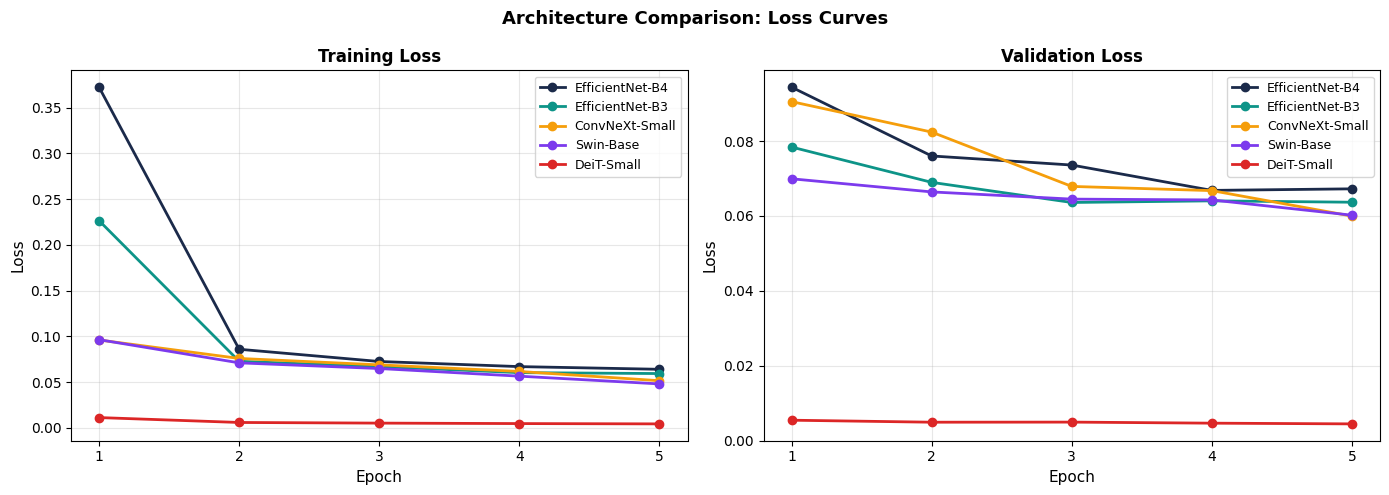

Saved: fig_architecture_loss.png and .pdf


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for exp in arch_runs:
    if exp not in results:
        continue
    h = results[exp]['history']
    epochs_x = range(1, len(h['train_loss']) + 1)
    name = DISPLAY_NAMES[exp].replace(' (CE, 5 ep)', '')
    
    axes[0].plot(epochs_x, h['train_loss'], 'o-', linewidth=2,
                 label=name, color=COLORS[exp])
    axes[1].plot(epochs_x, h['val_loss'], 'o-', linewidth=2,
                 label=name, color=COLORS[exp])

for ax, title in zip(axes, ['Training Loss', 'Validation Loss']):
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Loss', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xticks(range(1, 6))

plt.suptitle('Architecture Comparison: Loss Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_architecture_loss.png'), dpi=200, bbox_inches='tight')
plt.savefig(os.path.join(FIGURES_DIR, 'fig_architecture_loss.pdf'), bbox_inches='tight')
plt.show()
print('Saved: fig_architecture_loss.png and .pdf')

## Cell 6 — Imbalance handling: CE vs Focal Loss on Swin-Base

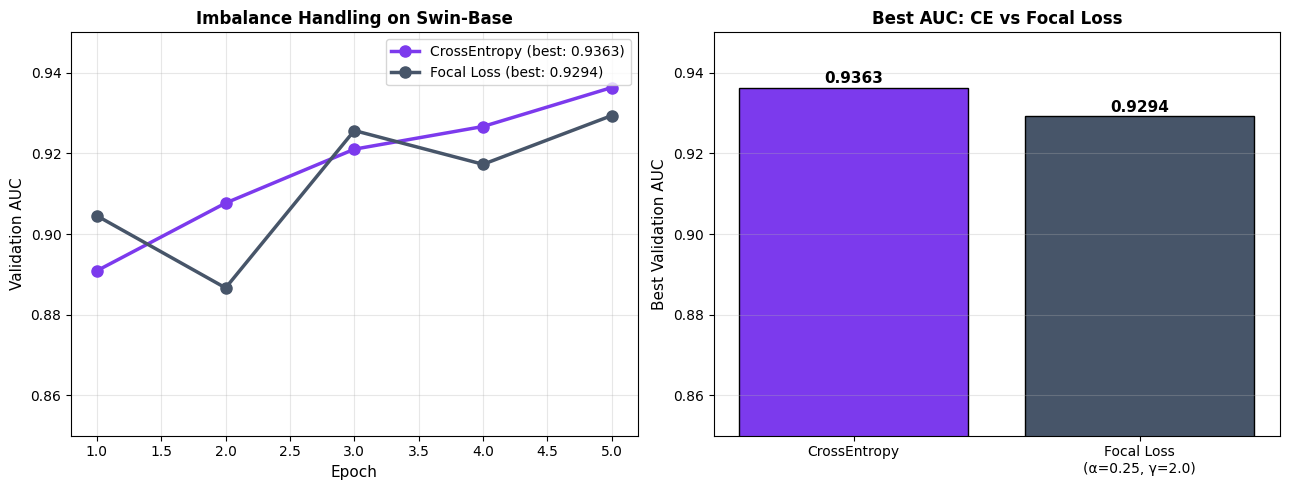

Saved: fig_imbalance_handling.png and .pdf

Δ Focal − CE = -0.0069 (focal hurt performance)


In [13]:
ce_exp = 'exp3_swin_base'
focal_exp = 'exp4b_swin_base_focal'

if ce_exp in results and focal_exp in results:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    
    # AUC comparison
    for exp, label in [(ce_exp, 'CrossEntropy'), (focal_exp, 'Focal Loss')]:
        h = results[exp]['history']
        epochs_x = range(1, len(h['val_auc']) + 1)
        axes[0].plot(epochs_x, h['val_auc'], 'o-', linewidth=2.5, markersize=8,
                     label=f'{label} (best: {results[exp]["best_auc"]:.4f})',
                     color=COLORS[exp])
    axes[0].set_xlabel('Epoch', fontsize=11)
    axes[0].set_ylabel('Validation AUC', fontsize=11)
    axes[0].set_title('Imbalance Handling on Swin-Base', fontsize=12, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(alpha=0.3)
    axes[0].set_ylim([0.85, 0.95])
    
    # Bar chart of best AUC
    names = ['CrossEntropy', 'Focal Loss\n(α=0.25, γ=2.0)']
    aucs = [results[ce_exp]['best_auc'], results[focal_exp]['best_auc']]
    colors_bar = [COLORS[ce_exp], COLORS[focal_exp]]
    bars = axes[1].bar(names, aucs, color=colors_bar, edgecolor='black')
    axes[1].set_ylabel('Best Validation AUC', fontsize=11)
    axes[1].set_title('Best AUC: CE vs Focal Loss', fontsize=12, fontweight='bold')
    axes[1].set_ylim([0.85, 0.95])
    axes[1].grid(alpha=0.3, axis='y')
    for bar, auc in zip(bars, aucs):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                     f'{auc:.4f}', ha='center', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'fig_imbalance_handling.png'), dpi=200, bbox_inches='tight')
    plt.savefig(os.path.join(FIGURES_DIR, 'fig_imbalance_handling.pdf'), bbox_inches='tight')
    plt.show()
    print('Saved: fig_imbalance_handling.png and .pdf')
    
    delta = results[focal_exp]['best_auc'] - results[ce_exp]['best_auc']
    print(f'\nΔ Focal − CE = {delta:+.4f} (focal {"helped" if delta > 0 else "hurt"} performance)')
else:
    print('Both CE and Focal experiments not found — skipping imbalance plot.')

## Cell 7 — Training duration: 5 vs 15 epochs on Swin-Base

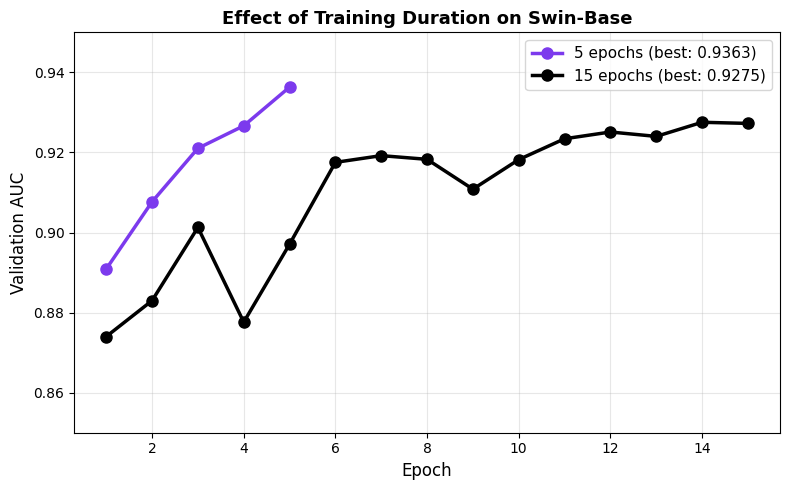

Saved: fig_training_duration.png and .pdf

Δ (15 ep − 5 ep) = -0.0088
15-epoch best epoch: 14


In [14]:
short_exp = 'exp3_swin_base'
long_exp = 'exp_final_swin_15epoch'

if short_exp in results and long_exp in results:
    fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    for exp, label in [(short_exp, '5 epochs'), (long_exp, '15 epochs')]:
        h = results[exp]['history']
        epochs_x = range(1, len(h['val_auc']) + 1)
        ax.plot(epochs_x, h['val_auc'], 'o-', linewidth=2.5, markersize=8,
                label=f'{label} (best: {results[exp]["best_auc"]:.4f})',
                color=COLORS[exp])
    
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Validation AUC', fontsize=12)
    ax.set_title('Effect of Training Duration on Swin-Base', fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)
    ax.set_ylim([0.85, 0.95])
    
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'fig_training_duration.png'), dpi=200, bbox_inches='tight')
    plt.savefig(os.path.join(FIGURES_DIR, 'fig_training_duration.pdf'), bbox_inches='tight')
    plt.show()
    print('Saved: fig_training_duration.png and .pdf')
    
    delta = results[long_exp]['best_auc'] - results[short_exp]['best_auc']
    print(f'\nΔ (15 ep − 5 ep) = {delta:+.4f}')
    print(f'15-epoch best epoch: {int(np.argmax(results[long_exp]["history"]["val_auc"])) + 1}')
else:
    print('Both duration experiments not found — skipping duration plot.')

## Cell 8 — Headline table (markdown, ready for report)

In [15]:
# Build the headline LaTeX-ready table
print('## Architecture Comparison (5 epochs, CrossEntropy, fold 0)\n')
print('| Rank | Model | Type | Parameters | Image Size | Best Val AUC |')
print('|------|-------|------|------------|------------|---------------|')

arch_only = [r for r in rows if r['Epochs'] == 5 and 'Focal' not in r['Experiment']]
arch_only = sorted(arch_only, key=lambda x: -x['Best AUC'])

for i, r in enumerate(arch_only):
    rank = i + 1
    name_short = r['Experiment'].replace(' (CE, 5 ep)', '')
    print(f"| {rank} | {name_short} | {r['Type']} | {r['Params']} | {r['Img']} | **{r['Best AUC']:.4f}** |")

print('\n')
print('## Imbalance Handling Experiment (Swin-Base)\n')
if 'exp4_swin_base' in results and 'exp4b_swin_base_focal' in results:
    ce = results['exp4_swin_base']['best_auc']
    focal = results['exp4b_swin_base_focal']['best_auc']
    print('| Loss | Best Val AUC | Δ vs CE |')
    print('|------|--------------|---------|')
    print(f'| CrossEntropy | {ce:.4f} | — |')
    print(f'| Focal Loss (α=0.25, γ=2.0) | {focal:.4f} | {focal-ce:+.4f} |')

print('\n')
print('## Effect of Training Duration (Swin-Base, CrossEntropy)\n')
if 'exp4_swin_base' in results and 'exp_final_swin_15epoch' in results:
    short = results['exp4_swin_base']['best_auc']
    long = results['exp_final_swin_15epoch']['best_auc']
    short_epochs = len(results['exp4_swin_base']['history']['val_auc'])
    long_epochs = len(results['exp_final_swin_15epoch']['history']['val_auc'])
    print('| Training Epochs | Best Val AUC |')
    print('|-----------------|--------------|')
    print(f'| {short_epochs} | {short:.4f} |')
    print(f'| {long_epochs} | {long:.4f} |')

## Architecture Comparison (5 epochs, CrossEntropy, fold 0)

| Rank | Model | Type | Parameters | Image Size | Best Val AUC |
|------|-------|------|------------|------------|---------------|
| 1 | Swin-Base | Transformer | 86.8M | 224 | **0.9363** |
| 2 | ConvNeXt-Small | CNN | 49.5M | 384 | **0.9289** |
| 3 | DeiT-Small | Transformer | 21.7M | 224 | **0.9183** |
| 4 | EfficientNet-B3 | CNN | 10.7M | 384 | **0.9126** |
| 5 | EfficientNet-B4 | CNN | 17.6M | 384 | **0.9085** |


## Imbalance Handling Experiment (Swin-Base)



## Effect of Training Duration (Swin-Base, CrossEntropy)



## Cell 9 — Final summary

In [16]:
print('=' * 70)
print('FINAL RESULTS SUMMARY')
print('=' * 70)

# Best overall
best = max(results.values(), key=lambda x: x['best_auc'])
best_name = [k for k, v in results.items() if v is best][0]
print(f'\nBest overall result: {DISPLAY_NAMES.get(best_name, best_name)}')
print(f'Best Val AUC:        {best["best_auc"]:.4f}')

# Architecture winner
arch_results = {k: v for k, v in results.items() if k in arch_runs}
if arch_results:
    arch_winner = max(arch_results.values(), key=lambda x: x['best_auc'])
    arch_winner_name = [k for k, v in arch_results.items() if v is arch_winner][0]
    print(f'\nArchitecture comparison winner (5 ep, CE):')
    print(f'  {DISPLAY_NAMES[arch_winner_name]}: AUC = {arch_winner["best_auc"]:.4f}')

# Total compute
total_minutes = sum(sum(r['history']['time_min']) for r in results.values())
print(f'\nTotal compute used: {total_minutes:.1f} min ({total_minutes/60:.1f} hours)')
print(f'Total experiments:  {len(results)}')
print(f'\nFigures saved to: {os.path.abspath(FIGURES_DIR)}')

FINAL RESULTS SUMMARY

Best overall result: Swin-Base (CE, 5 ep)
Best Val AUC:        0.9363

Architecture comparison winner (5 ep, CE):
  Swin-Base (CE, 5 ep): AUC = 0.9363

Total compute used: 572.7 min (9.5 hours)
Total experiments:  7

Figures saved to: /Users/pallaviroysawant/projects/melanomaClassificationAML/figures
